In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [2]:
df=pd.read_excel("09_02_well-1343E.xlsx")
df

,Depth,DTCO,SPHI,RHOM,HCGR
0,103.5533,199.0909,0.597580,1.3836,32.2805
1,104.1000,198.7273,0.596066,1.5431,35.1178
2,106.0523,195.6364,0.583193,1.7525,33.9707
3,109.9571,195.6364,0.583193,1.7672,38.0664
4,111.9094,198.0000,0.593037,1.7249,40.8417
...,...,...,...,...,...
352,717.4541,168.7273,0.471128,1.7436,43.4126
353,718.9379,169.6364,0.474914,1.7171,44.0442
354,720.3436,166.3636,0.461284,1.7157,41.7514
355,721.8274,161.6364,0.441597,1.6435,37.8892


### Data Quality Check

In [3]:
# Calculate depth differences
depth_diff = df['Depth'].diff().dropna()
unique_diffs = depth_diff.unique()
unique_diffs

array([0.5467, 1.9523, 3.9048, 3.2019, 1.9524, 2.5771, 2.6552, 2.5771,
       5.1542, 2.6553, 1.9523, 2.5772, 3.2799, 3.8267, 2.6552, 1.9524,
       1.8743, 1.2495, 3.28  , 1.2495, 1.3276, 0.6247, 1.3276, 0.6248,
       4.5295, 1.9524, 1.2496, 3.2019, 0.7029, 3.28  , 2.5771, 2.5771,
       2.6552, 3.9047, 0.6247, 1.3276, 1.2496, 0.7028, 3.2019, 1.8742,
       1.2495, 1.9523, 0.7028, 2.8895, 2.1086, 2.1866, 1.4057, 1.4838,
       1.4057, 1.4838, 2.1085, 2.1867, 3.5924, 0.781 , 2.1867, 0.7809,
       0.7809, 2.1866, 2.1085, 2.1867, 1.4057, 2.1086, 2.1085, 0.781 ,
       1.4838, 0.7809, 2.1086, 2.8114, 0.781 , 3.5923])

In [4]:
sampling_interval=df.Depth[1]-df.Depth[0]
sampling_interval

np.float64(0.5467000000000013)

In [5]:
# Check if sampling is uniform
if len(unique_diffs) == 1:
    print(f"\n✓ UNIFORM SAMPLING: All intervals are {unique_diffs[0]:.4f}")
    expected_interval = unique_diffs[0]
else:
    print(f"\n✗ NON-UNIFORM SAMPLING: Found {len(unique_diffs)} different intervals")
    print(f"  Interval statistics:")
    print(f"    Mean: {depth_diff.mean():.4f}")
    print(f"    Std:  {depth_diff.std():.4f}")
    print(f"    Min:  {depth_diff.min():.4f}")
    print(f"    Max:  {depth_diff.max():.4f}")


✗ NON-UNIFORM SAMPLING: Found 70 different intervals
  Interval statistics:
    Mean: 1.7468
    Std:  0.7953
    Min:  0.5467
    Max:  5.1542


# 1. Unsupervised Machine learning 

### Principle Component Analysis (PCA) followed by Kmeans Clustering

In [6]:
from sklearn.preprocessing import StandardScaler

X = df[['RHOM','SPHI','HCGR','DTCO']]
X_scaled = StandardScaler().fit_transform(X)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_k'] = kmeans.fit_predict(X_scaled)

C:\Users\Tanmay\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [9]:
df.describe()

,Depth,DTCO,SPHI,RHOM,HCGR,cluster_k
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,428.688903,179.661820,0.516666,1.707048,38.304226,1.126050
std,170.420970,9.986746,0.041591,0.105516,6.540934,0.809577
min,103.553300,160.909100,0.438569,1.154800,21.860500,0.000000
25%,291.682900,170.710600,0.479388,1.656300,33.584100,0.000000
50%,436.079700,179.636400,0.516560,1.717100,37.574200,1.000000
75%,566.341300,187.636400,0.549877,1.776500,42.622400,2.000000
max,725.419800,199.090900,0.597580,1.907200,61.249300,2.000000


In [14]:
def log_plots(cluster_label, method='Kmeans', lithology_dict=None): 
    fig, axs = plt.subplots(1, 5, figsize=(13, 12), sharey=True)
    fig.subplots_adjust(wspace=0.15, right=0.88)
    
    depth_col = 'Depth'
    logs = ['HCGR', 'RHOM', 'SPHI', 'DTCO']
    titles = ['HCGR (gAPI)', 'RHOM (g/cc)', 'SPHI (v/v)', 'DTCO (us/ft)']
    xranges = [(20, 70), (1.0, 2.0), (0.4, 0.8), (150, 210)]
    colors = ['g','r','blue','gold']

    depths = df[depth_col].values
    labels = cluster_label.astype(str).values

    # Ensure sorting
    sort_idx = np.argsort(depths)
    depths = depths[sort_idx]
    labels = labels[sort_idx]

    # LOG TRACKS
    for i, (log, title, xrange, color) in enumerate(zip(logs, titles, xranges, colors)):
        axs[i].plot(df[log], df[depth_col], color=color, linewidth=1)
        axs[i].set_xlim(xrange)
        axs[i].set_xlabel(title, fontsize=12)
        axs[i].xaxis.set_label_position('top')
        axs[i].xaxis.tick_top()
        axs[i].grid(True, alpha=0.3)
        axs[i].invert_yaxis()
        axs[i].set_ylim(depths.max(), depths.min())

  
    # lithology
    ax_lith = axs[4]
    
    clusters = cluster_label.values

    # Ensure sorting (same as logs)
    clusters = clusters[sort_idx]
    
    # Create color list in correct order of cluster IDs
    cluster_ids = sorted(lithology_dict.keys())
    colors = [lithology_dict[i]['color'] for i in cluster_ids]
    
    # Create colormap
    import matplotlib.colors as mcolors
    cmap = mcolors.ListedColormap(colors)
    
    # Create image
    width = 1
    img = np.tile(clusters[:, None], (1, width))
    
    ax_lith.imshow(
        img,
        aspect='auto',
        cmap=cmap,
        vmin=min(cluster_ids),
        vmax=max(cluster_ids),
        extent=[0, 1, depths.max(), depths.min()]
    )
    
    ax_lith.set_xlabel('Electrofacies', fontsize=12)
    ax_lith.xaxis.set_label_position('top')
    ax_lith.xaxis.tick_top()
    ax_lith.set_xticks([])
    ax_lith.spines['top'].set_visible(False)
    ax_lith.spines['bottom'].set_visible(False)
    

    # COLORBAR (manual lithology legend)
    from matplotlib.patches import Rectangle

    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

    for i, (cluster_id, info) in enumerate(lithology_dict.items()):
        y = len(lithology_dict) - i - 1

        rect = Rectangle((0, y), 1, 1,
                         facecolor=info['color'],
                         edgecolor='black')

        cbar_ax.add_patch(rect)

        cbar_ax.text(1.2, y + 0.5, info['name'],
                     va='center', ha='left',
                     fontsize=10, rotation=90)

    cbar_ax.set_xlim(0, 1)
    cbar_ax.set_ylim(0, len(lithology_dict))
    cbar_ax.set_xticks([])
    cbar_ax.set_yticks([])

    for spine in cbar_ax.spines.values():
        spine.set_visible(False)

    # FINAL FORMATTING
    axs[0].set_ylabel('Depth (m)', fontsize=12)

    for ax in axs:
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.tick_params(axis='y', labelsize=10)

    plt.suptitle(f'Well Log Composite Plot with Electrofacies: {method}', fontsize=14, y=0.94)
    plt.show()

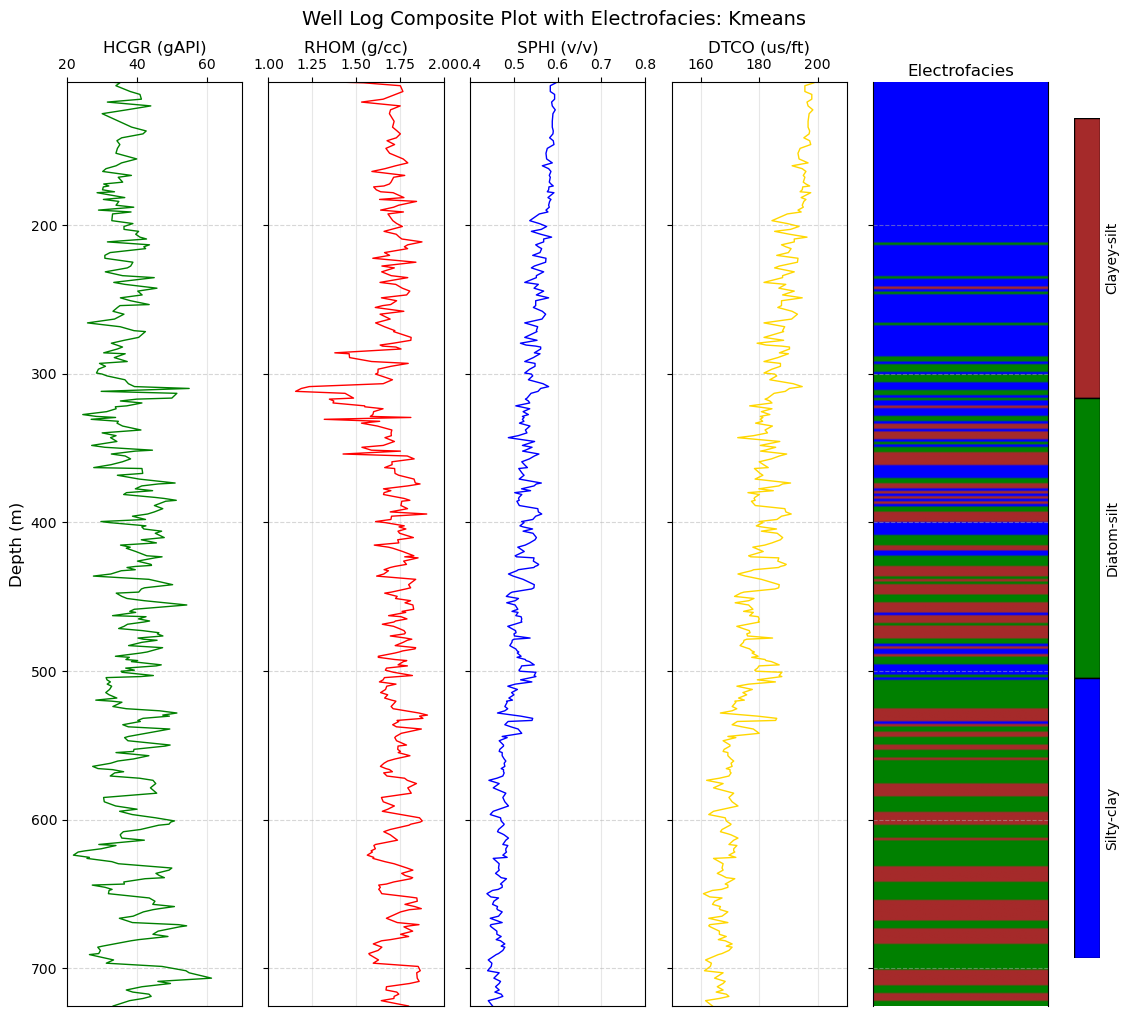

In [15]:
# Define lithology names and colors
lith_kmeans = {
    0: {'name': 'Clayey-silt', 'color': 'brown'},
    1: {'name': 'Diatom-silt', 'color': 'green'},
    2: {'name': 'Silty-clay', 'color': 'blue'}
}
log_plots(cluster_label=df['cluster_k'], method='Kmeans', lithology_dict=lith_kmeans)

In [16]:
"""
we have to adjust this based on geological characteristics of corresponding rock types
"""

mapping_k = {
    0: 'Clayey-silt',
    1: 'Diatom-silt',
    2: 'Silty-clay'
}

df['EF_Kmeans'] = df['cluster_k'].map(mapping_k)

### Fuzzy C Means Clustering

In [17]:
import skfuzzy as fuzz

# Transpose for FCM (features x samples)
X_t = X_scaled.T

# 3. FCM CLUSTERING
n_clusters = 3 

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_t,
    c=n_clusters,
    m=2,              # fuzziness (2 is standard)
    error=0.005,
    maxiter=1000,
    init=None)

# Hard cluster labels
cluster_labels = np.argmax(u, axis=0)
df['cluster_fcm'] = cluster_labels

# Membership values (important!)
for i in range(n_clusters):
    df[f'Membership_{i}'] = u[i]

In [18]:
df

,Depth,DTCO,SPHI,RHOM,HCGR,cluster_k,EF_Kmeans,cluster_fcm,Membership_0,Membership_1,Membership_2
0,103.5533,199.0909,0.597580,1.3836,32.2805,2,Silty-clay,1,0.298282,0.518955,0.182762
1,104.1000,198.7273,0.596066,1.5431,35.1178,2,Silty-clay,1,0.193199,0.681721,0.125080
2,106.0523,195.6364,0.583193,1.7525,33.9707,2,Silty-clay,1,0.083232,0.853782,0.062986
3,109.9571,195.6364,0.583193,1.7672,38.0664,2,Silty-clay,1,0.075213,0.855143,0.069644
4,111.9094,198.0000,0.593037,1.7249,40.8417,2,Silty-clay,1,0.097917,0.807692,0.094391
...,...,...,...,...,...,...,...,...,...,...,...
352,717.4541,168.7273,0.471128,1.7436,43.4126,0,Clayey-silt,2,0.119421,0.037946,0.842633
353,718.9379,169.6364,0.474914,1.7171,44.0442,0,Clayey-silt,2,0.147634,0.047097,0.805269
354,720.3436,166.3636,0.461284,1.7157,41.7514,0,Clayey-silt,2,0.303570,0.072221,0.624209
355,721.8274,161.6364,0.441597,1.6435,37.8892,1,Diatom-silt,0,0.544593,0.108884,0.346523


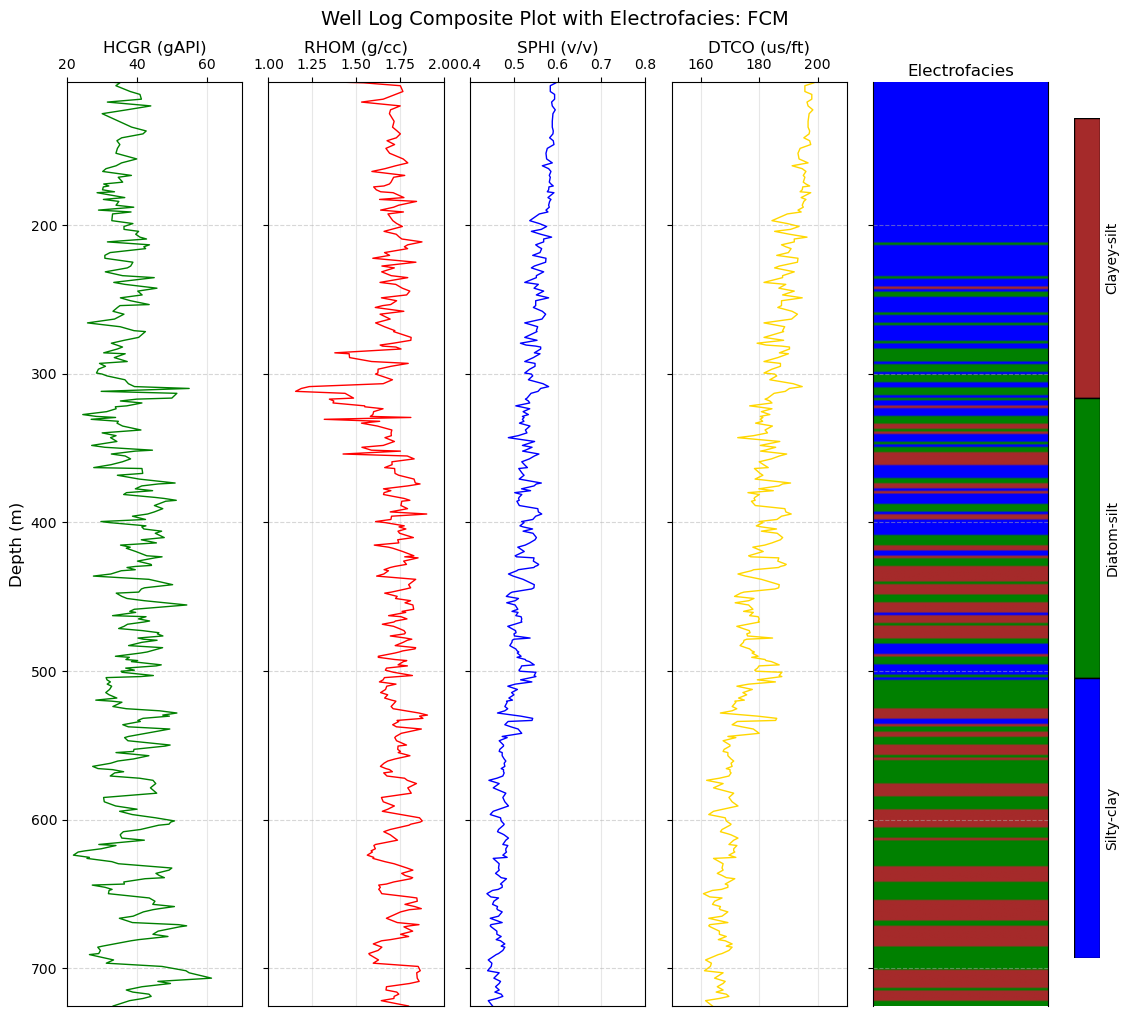

In [19]:
# Define lithology names and colors
"""Since FCM assigns cluster indices (0,1,2) arbitrarily in each run, 
abels must be assigned each time accordindly."""

lith_fcm = {
    2: {'name': 'Clayey-silt', 'color': 'brown'},
    0: {'name': 'Diatom-silt', 'color': 'green'},
    1: {'name': 'Silty-clay', 'color': 'blue'}
}
log_plots(cluster_label=df['cluster_fcm'], method='FCM', lithology_dict=lith_fcm)

In [20]:
mapping_f = {
    2: 'Clayey-silt',
    0: 'Diatom-silt',
    1: 'Silty-clay'
}

df['EF_FCM'] = df['cluster_fcm'].map(mapping_f)
df

,Depth,DTCO,SPHI,RHOM,HCGR,cluster_k,EF_Kmeans,cluster_fcm,Membership_0,Membership_1,Membership_2,EF_FCM
0,103.5533,199.0909,0.597580,1.3836,32.2805,2,Silty-clay,1,0.298282,0.518955,0.182762,Silty-clay
1,104.1000,198.7273,0.596066,1.5431,35.1178,2,Silty-clay,1,0.193199,0.681721,0.125080,Silty-clay
2,106.0523,195.6364,0.583193,1.7525,33.9707,2,Silty-clay,1,0.083232,0.853782,0.062986,Silty-clay
3,109.9571,195.6364,0.583193,1.7672,38.0664,2,Silty-clay,1,0.075213,0.855143,0.069644,Silty-clay
4,111.9094,198.0000,0.593037,1.7249,40.8417,2,Silty-clay,1,0.097917,0.807692,0.094391,Silty-clay
...,...,...,...,...,...,...,...,...,...,...,...,...
352,717.4541,168.7273,0.471128,1.7436,43.4126,0,Clayey-silt,2,0.119421,0.037946,0.842633,Clayey-silt
353,718.9379,169.6364,0.474914,1.7171,44.0442,0,Clayey-silt,2,0.147634,0.047097,0.805269,Clayey-silt
354,720.3436,166.3636,0.461284,1.7157,41.7514,0,Clayey-silt,2,0.303570,0.072221,0.624209,Clayey-silt
355,721.8274,161.6364,0.441597,1.6435,37.8892,1,Diatom-silt,0,0.544593,0.108884,0.346523,Diatom-silt


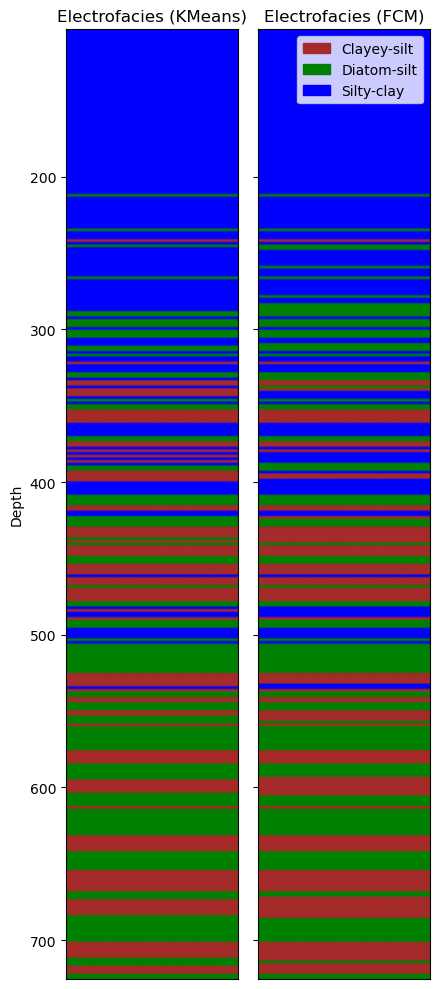

In [21]:
depths = df['Depth'].values
labels_km = df['EF_Kmeans'].values
labels_fcm = df['EF_FCM'].values

lithology_colors = {
    'Clayey-silt': 'brown',
    'Diatom-silt': 'green',
    'Silty-clay': 'blue'
}

lith_names = list(lithology_colors.keys())
lith_to_num = {l:i for i,l in enumerate(lith_names)}

def labels_to_numeric(labels):
    return np.array([lith_to_num.get(l, -1) for l in labels])

num_km = labels_to_numeric(labels_km)
num_fcm = labels_to_numeric(labels_fcm)

width = 20
img_km = np.tile(num_km[:, None], (1, width))
img_fcm = np.tile(num_fcm[:, None], (1, width))

cmap = mcolors.ListedColormap([lithology_colors[l] for l in lith_names])
fig, axs = plt.subplots(1, 2, figsize=(4.5, 10), sharey=True)

# KMeans
im0 = axs[0].imshow(
    img_km,
    aspect='auto',
    cmap=cmap,
    extent=[0, 1, depths.max(), depths.min()]
)
axs[0].set_title("Electrofacies (KMeans)")
axs[0].set_xticks([])

# FCM
im1 = axs[1].imshow(
    img_fcm,
    aspect='auto',
    cmap=cmap,
    extent=[0, 1, depths.max(), depths.min()]
)
axs[1].set_title("Electrofacies (FCM)")
axs[1].set_xticks([])

axs[0].set_ylabel("Depth")

# legend
legend_patches = [
    mpatches.Patch(color=lithology_colors[l], label=l)
    for l in lith_names
]
axs[1].legend(handles=legend_patches, loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
# MATCHING ANALYSIS
df['Match'] = df['EF_Kmeans'] == df['EF_FCM']

n_total = len(df)
n_match = df['Match'].sum()
n_mismatch = n_total - n_match

print("Total samples:", n_total)
print("Matching:", n_match)
print("Not Matching:", n_mismatch)

print("Matching %:", (n_match / n_total) * 100)
print("Mismatch %:", (n_mismatch / n_total) * 100)

Total samples: 357
Matching: 329
Not Matching: 28
Matching %: 92.15686274509804
Mismatch %: 7.8431372549019605


Supervised machine learning requires labeled data, which is not directly available in this study. Therefore, unsupervised clustering techniques such as K-means and Fuzzy C-Means clustering were first applied to generate electrofacies-based pseudo-labels. These derived labels were then used to train supervised models.

**Continuing with FCM Electrofacies Rock types as Labels for training Supervised Machine learning classification Models.**

# 2. Supervised Machine Learning 

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [42]:
# DATA PREPARATION
features = ['HCGR', 'DTCO', 'SPHI', 'RHOM']
X = df[features].values
y = df['EF_FCM'].values

# Encode labels if text
le = LabelEncoder()
y_encoded = le.fit_transform(y)
'''Splitting the data into 3 sets 60% for training model 20% for vadiation and rest
    20% for blind prediction and statistical metric evaluation'''
# First split: 80% train+val, 20% blind test
X_temp, X_blind, y_temp, y_blind = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Second split: from remaining 80%, split into 60% train and 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 0.25 of 80% = 20%
    random_state=42,
    stratify=y_temp
)

In [43]:
# EVALUATION FUNCTION
def evaluate_model(name, model):
    y_pred_val = model.predict(X_val)
    print(f"\n{name} Results on Validation Set")
    print("="*40)
    print("Best Params:", model.best_params_)
    print("Accuracy:", accuracy_score(y_val, y_pred_val))
    print("\nClassification Report:\n", classification_report(y_val, y_pred_val))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_val))

    return y_pred_val

### Random Forest

In [44]:
rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 3, 4, 5]}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

y_pred_rf = evaluate_model("Random Forest", grid_rf)


Random Forest Results on Validation Set
Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy: 0.9444444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91        20
           1       1.00      1.00      1.00        24
           2       1.00      0.86      0.92        28

    accuracy                           0.94        72
   macro avg       0.94      0.95      0.94        72
weighted avg       0.95      0.94      0.94        72

Confusion Matrix:
 [[20  0  0]
 [ 0 24  0]
 [ 4  0 24]]


### ANN (MLP)

In [45]:
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        max_iter=2000,
        early_stopping=True,   # prevents overfitting
        n_iter_no_change=20,
        random_state=42
    ))
])

param_mlp = {
    'clf__hidden_layer_sizes': [
        (50,), (100,), (150,),
        (50,50), (100,50)
    ],
    'clf__activation': ['relu', 'tanh'],
    'clf__solver': ['adam'],   # best for most cases
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    pipe_mlp,
    param_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_mlp.fit(X_train, y_train)

y_pred_mlp = evaluate_model("ANN (MLP)", grid_mlp)

Fitting 5 folds for each of 60 candidates, totalling 300 fits

ANN (MLP) Results on Validation Set
Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (50, 50), 'clf__learning_rate_init': 0.001, 'clf__solver': 'adam'}
Accuracy: 0.9861111111111112

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      0.96      0.98        24
           2       0.97      1.00      0.98        28

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72

Confusion Matrix:
 [[20  0  0]
 [ 0 23  1]
 [ 0  0 28]]


# 3. Statistical Performance Measure 

In [51]:
# statistical metrics 
def correlation_coefficient(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0,1]
    
def index_of_agreement(y_true, y_pred):
    y_mean = np.mean(y_true)
    
    numerator = np.sum((y_pred - y_true)**2)
    denominator = np.sum((np.abs(y_pred - y_mean) + np.abs(y_true - y_mean))**2)
    
    return 1 - (numerator / denominator)

def reduction_of_error(y_true, y_pred):
    y_mean = np.mean(y_true)
    
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true)**2)
    
    return 1 - (numerator / denominator)

In [57]:
y_pred_blind_rf = grid_rf.predict(X_blind)

r = correlation_coefficient(y_blind, y_pred_blind_rf)
ioa = index_of_agreement(y_blind, y_pred_blind_rf)
re = reduction_of_error(y_blind, y_pred_blind_rf)
print('Random Forest\n')
print("Correlation Coefficient (R):", r)
print("Index of Agreement (d):", ioa)
print("Reduction of Error (RE):", re)

Random Forest

Correlation Coefficient (R): 0.968073997907129
Index of Agreement (d): 0.9837902741644987
Reduction of Error (RE): 0.9779411764705882


In [56]:
y_pred_blind_mlp = grid_mlp.predict(X_blind)

r = correlation_coefficient(y_blind, y_pred_blind_mlp)
ioa = index_of_agreement(y_blind, y_pred_blind_mlp)
re = reduction_of_error(y_blind, y_pred_blind_mlp)

print('Multi Layer Perceptron (MLP/ANN)\n')
print("Correlation Coefficient (R):", r)
print("Index of Agreement (d):", ioa)
print("Reduction of Error (RE):", re)

Multi Layer Perceptron (MLP/ANN)

Correlation Coefficient (R): 0.9474357107537607
Index of Agreement (d): 0.9728352002146354
Reduction of Error (RE): 0.9632352941176471
